In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

In [6]:
# load the data
data = pd.read_csv('diabetes_dataset.csv')

##### As Per The EDA Droping Fertures that has with One to One correlation with Target ["diagnosed_diabetes"]

In [ ]:
#Remove any Higly correlated features as per EDA analysis
data = data.drop(columns=['diabetes_stage','diabetes_risk_score'])

#### Spliit Data to  train on one part and test on unseen data.

In [8]:
# Spliit Data to  train on one part and test on unseen data.
X = data.drop('diagnosed_diabetes', axis=1)
y = data['diagnosed_diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

##### Try to Exacute Decion Tree with out Encoding data since Trees Algorithms Trees split data based on thresholds so they do not assume numeric order.}

In [9]:
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)
print("Decision Tree Classifier Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

ValueError: could not convert string to float: 'Female'

Evan though Tree algorthms like [Decision Tree / Random Forest] not needed to encode catagorical fertures to numarical since using scikit-learn we  must still need to  convert categorical text into  numbers

#### One Hot Encode Data

In [10]:
## One Hot Encode Data
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

##### Decision Tree Clasifier

In [11]:
## Decision Tree Classifier with Encoded Data
dt_classifier_encoded = DecisionTreeClassifier(random_state=42)
dt_classifier_encoded.fit(X_train_encoded, y_train)
y_pred_dt_encoded = dt_classifier_encoded.predict(X_test_encoded)
print("Decision Tree Classifier with Encoded Data Accuracy:", accuracy_score(y_test, y_pred_dt_encoded))
print(classification_report(y_test, y_pred_dt_encoded))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt_encoded))

Decision Tree Classifier with Encoded Data Accuracy: 0.85995
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      8000
           1       0.88      0.89      0.88     12000

    accuracy                           0.86     20000
   macro avg       0.86      0.85      0.85     20000
weighted avg       0.86      0.86      0.86     20000

Confusion Matrix:
 [[ 6493  1507]
 [ 1294 10706]]


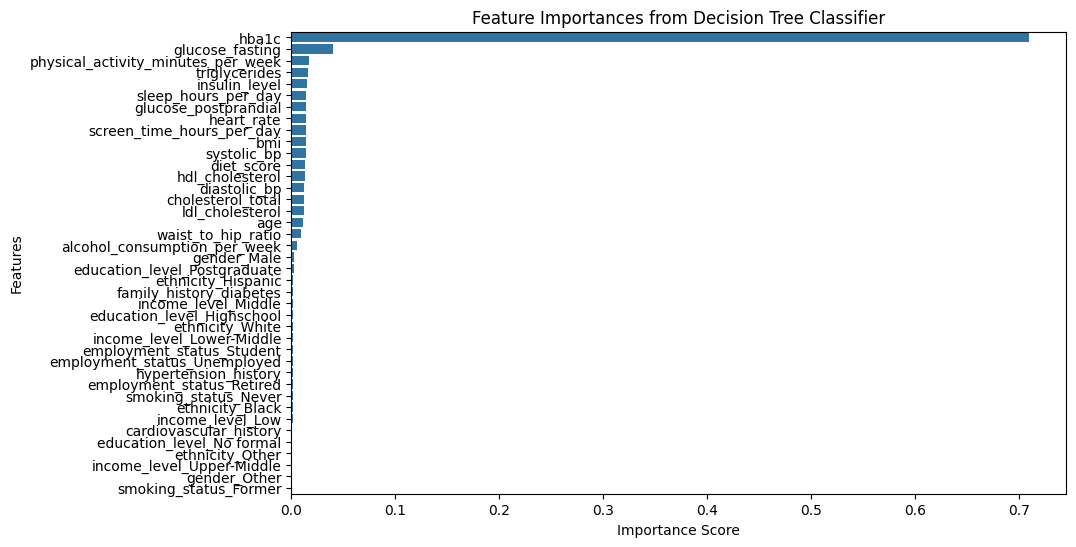

In [13]:
# Decision Tree Ferture Importance
feature_importances = pd.Series(dt_classifier_encoded.feature_importances_, index=X_train_encoded.columns)
feature_importances = feature_importances.sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title('Feature Importances from Decision Tree Classifier')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

#### Random Forest Classifier

In [14]:
## Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_encoded, y_train)
y_pred_rf = rf_classifier.predict(X_test_encoded)
print("Random Forest Classifier Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Classifier Accuracy: 0.91965
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      8000
           1       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000

Confusion Matrix:
 [[ 7995     5]
 [ 1602 10398]]


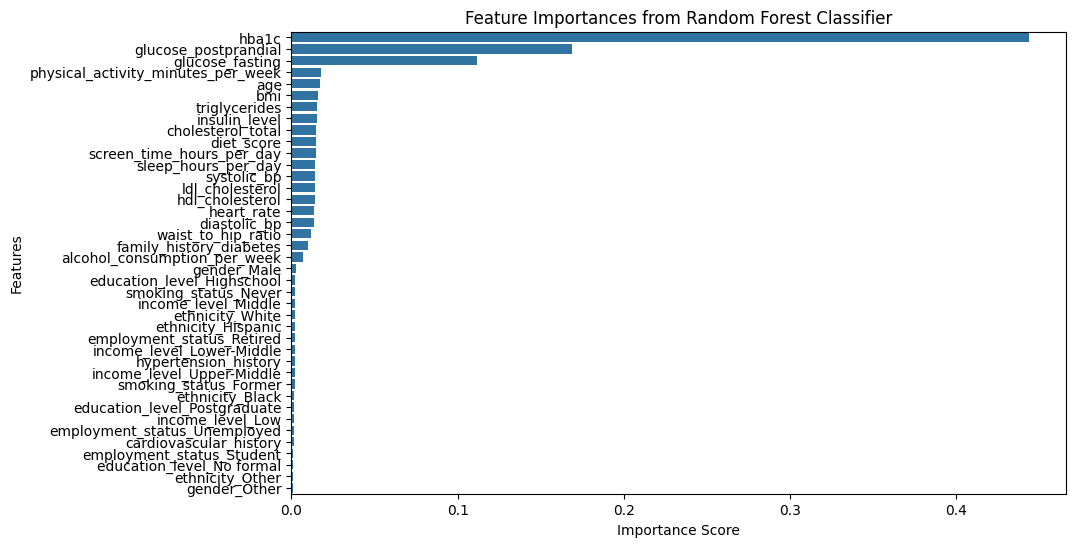

In [15]:
# random forest feature importance
rf_feature_importances = pd.Series(rf_classifier.feature_importances_, index=X_train_encoded.columns)
rf_feature_importances = rf_feature_importances.sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=rf_feature_importances, y=rf_feature_importances.index)
plt.title('Feature Importances from Random Forest Classifier')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

#### Logistic Regression Classifier 

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

All features are now on the same scale (mean=0, std=1), so no feature dominates because of large numbers. This step is importan for modules like Logistic Regression wich that rely on distance/gradients perform better.

In [17]:
## Logistic Regression Classifier
logreg_classifier = LogisticRegression(max_iter=1000, random_state=42)
logreg_classifier.fit(X_train_scaled, y_train)
y_pred_logreg = logreg_classifier.predict(X_test_scaled)
print("Logistic Regression Classifier Accuracy:", accuracy_score(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred_logreg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logreg))

Logistic Regression Classifier Accuracy: 0.86085
              precision    recall  f1-score   support

           0       0.84      0.81      0.82      8000
           1       0.88      0.90      0.89     12000

    accuracy                           0.86     20000
   macro avg       0.86      0.85      0.85     20000
weighted avg       0.86      0.86      0.86     20000

Confusion Matrix:
 [[ 6475  1525]
 [ 1258 10742]]


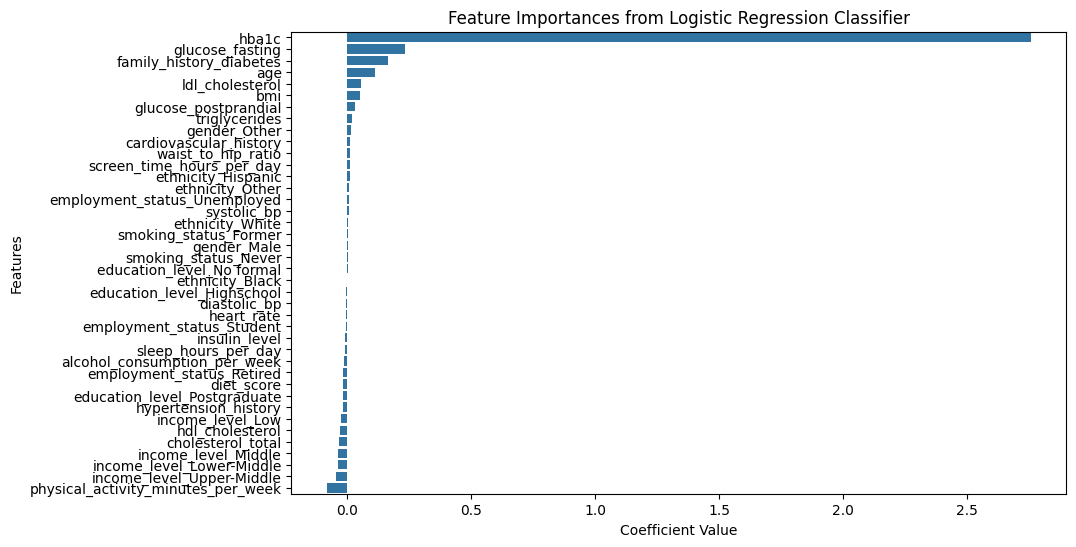

In [18]:
## logistic regression feature importance
logreg_feature_importances = pd.Series(logreg_classifier.coef_[0], index=X_train_encoded.columns)
logreg_feature_importances = logreg_feature_importances.sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=logreg_feature_importances, y=logreg_feature_importances.index)
plt.title('Feature Importances from Logistic Regression Classifier')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.show()

### Final Model Selection For The Given Data

In [20]:
# Model Comparison
models = {
    'Decision Tree': accuracy_score(y_test, y_pred_dt_encoded),
    'Random Forest': accuracy_score(y_test, y_pred_rf),
    'Logistic Regression': accuracy_score(y_test, y_pred_logreg)
}
print("Model Comparison (Accuracy Scores):")
for model, accuracy in models.items():
    print(f"{model}: {accuracy:.4f}")

Model Comparison (Accuracy Scores):
Decision Tree: 0.8599
Random Forest: 0.9196
Logistic Regression: 0.8609


In [23]:
# Model Comparison Usinfg F1 Score
from sklearn.metrics import f1_score
f1_scores = {
    'Decision Tree': f1_score(y_test, y_pred_dt_encoded),
    'Random Forest': f1_score(y_test, y_pred_rf),
    'Logistic Regression': f1_score(y_test, y_pred_logreg)
}
print("\nModel Comparison (F1 Scores):")
for model, f1 in f1_scores.items():
    print(f"{model}: {f1:.4f}")


Model Comparison (F1 Scores):
Decision Tree: 0.8843
Random Forest: 0.9283
Logistic Regression: 0.8853


In [21]:
# Model Comparison Using ROC AUC Score
roc_auc_scores = {
    'Decision Tree': roc_auc_score(y_test, dt_classifier_encoded.predict_proba(X_test_encoded)[:,1]),
    'Random Forest': roc_auc_score(y_test, rf_classifier.predict_proba(X_test_encoded)[:,1]),
    'Logistic Regression': roc_auc_score(y_test, logreg_classifier.predict_proba(X_test_scaled)[:,1])
}
print("\nModel Comparison (ROC AUC Scores):")
for model, roc_auc in roc_auc_scores.items():
    print(f"{model}: {roc_auc:.4f}")


Model Comparison (ROC AUC Scores):
Decision Tree: 0.8519
Random Forest: 0.9412
Logistic Regression: 0.9337


In [25]:
 # Take top 10 from each
top_n = 10
lr_top = logreg_feature_importances.head(top_n)
rf_top = rf_feature_importances.head(top_n)

# Combine into one DataFrame
importance_df = pd.DataFrame({
    "Logistic_Regression": lr_top,
    "Random_Forest": rf_top
}).fillna(0)

importance_df

,Logistic_Regression,Random_Forest
age,0.112899,0.017084
bmi,0.050292,0.016067
cardiovascular_history,0.013739,0.000000
cholesterol_total,0.000000,0.014931
diet_score,0.000000,0.014893
family_history_diabetes,0.163595,0.000000
gender_Other,0.016138,0.000000
glucose_fasting,0.231742,0.111880
glucose_postprandial,0.031210,0.168993
hba1c,2.757638,0.444040


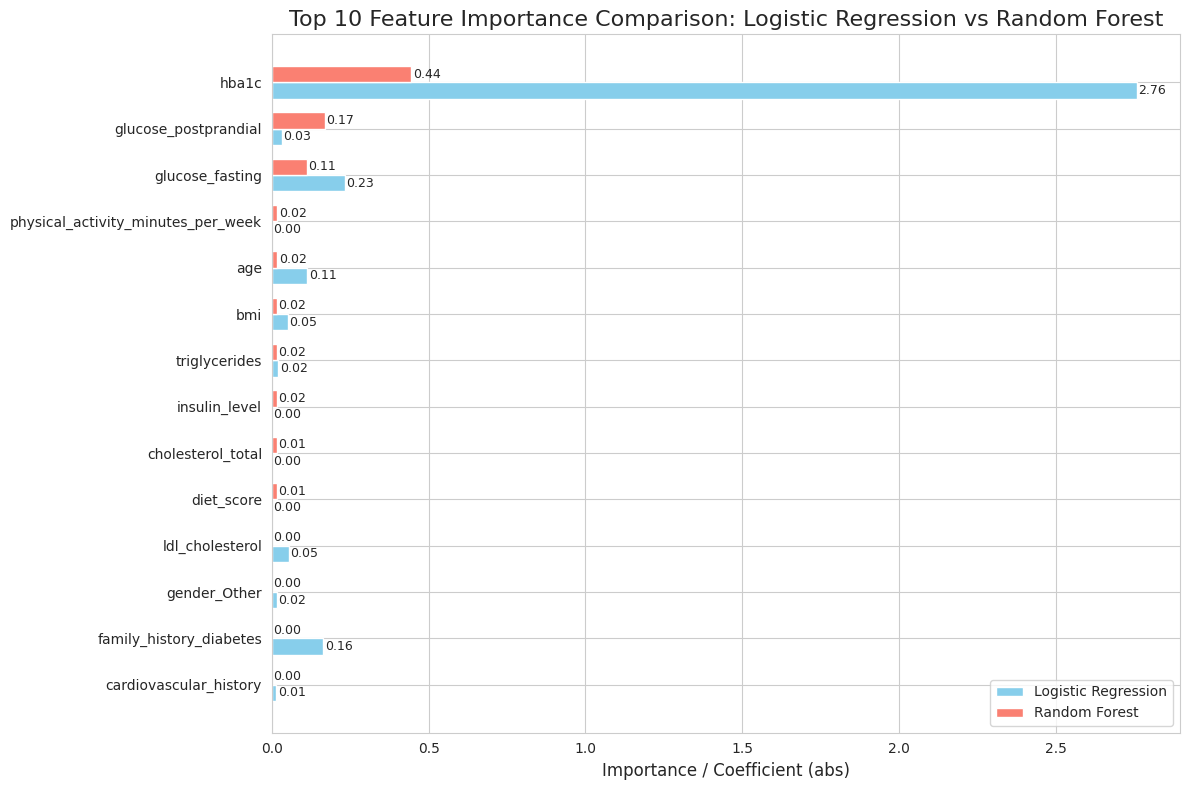

In [29]:
# Sort features by Random Forest for better visualization
importance_df_sorted = importance_df.sort_values(by="Random_Forest", ascending=True)

# Horizontal bar positions
y_pos = np.arange(len(importance_df_sorted))
height = 0.35  # bar thickness

plt.figure(figsize=(12,8))
sns.set_style("whitegrid")

# Plot Logistic Regression bars
plt.barh(y_pos - height/2, importance_df_sorted["Logistic_Regression"], 
         height=height, color='skyblue', label='Logistic Regression')

# Plot Random Forest bars
plt.barh(y_pos + height/2, importance_df_sorted["Random_Forest"], 
         height=height, color='salmon', label='Random Forest')

# Add data labels at the end of each bar
for i, (lr_val, rf_val) in enumerate(zip(importance_df_sorted["Logistic_Regression"], 
                                         importance_df_sorted["Random_Forest"])):
    plt.text(lr_val + 0.005, i - height/2, f'{lr_val:.2f}', va='center', fontsize=9)
    plt.text(rf_val + 0.005, i + height/2, f'{rf_val:.2f}', va='center', fontsize=9)

# Set y-ticks and labels
plt.yticks(y_pos, importance_df_sorted.index)
plt.xlabel("Importance / Coefficient (abs)", fontsize=12)
plt.title("Top 10 Feature Importance Comparison: Logistic Regression vs Random Forest", fontsize=16)
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
# Modal Comparison Summary
print("\nFinal Model Selection Summary:")
for model in models.keys():
    print(f"{model} - Accuracy: {models[model]:.4f}, F1 Score: {f1_scores[model]:.4f}, ROC AUC: {roc_auc_scores[model]:.4f}")



Final Model Selection Summary:
Decision Tree - Accuracy: 0.8599, F1 Score: 0.8843, ROC AUC: 0.8519
Random Forest - Accuracy: 0.9196, F1 Score: 0.9283, ROC AUC: 0.9412
Logistic Regression - Accuracy: 0.8609, F1 Score: 0.8853, ROC AUC: 0.9337
